In [215]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
%matplotlib inline

import csv


# Functions

In [216]:
def comma_to_left(string, index) -> bool:
    '''
    Checks if there is a comma to the left of the index in the string, ignoring spaces.
    '''
    while index >= 1:
        if string[index - 1] == ',':
            return True
        if string[index - 1] == ' ':
            index -= 1
        else:
            return False
    return False

def strip_optional_tags(string):
    '''
    Strips "optional" tags from the string, and strips descriptions of ingredients in parentheses
    '''
    # First, remove simple substrings
    string = string.replace("[", "").replace("]", "")
    string = string.replace("optionally", "").replace("optional", "")
    string = string.replace(":", "")
    
    # Handle parentheses: find all "("s
    # If no comma to the left, delete everything from "(" to ")"
    # If comma to the left, just delete "(" and ")"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            
            # Check if there's a comma to the left
            if comma_to_left(string, i):
                # Just delete "(" and ")", keep the content
                result.append(string[i+1:close_idx])
                i = close_idx + 1
            else:
                # Delete all text from "(" to ")" inclusive
                i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result)

def strip_optional_ingredients(string): # MAY NOT WORK
    '''
    Strips "optional" ingredients from the string, as well as descriptions of ingredients in parentheses.
    '''
    # First pass: Look for "(" or "[" from left to right
    # If one is found and there's a comma to the left, delete everything from that comma to the end
    i = 0
    while i < len(string):
        if string[i] in '([':
            if comma_to_left(string, i):
                # Delete everything from the comma to the end of the string
                j = i - 1
                while j >= 0:
                    if string[j] == ',':
                        string = string[:j]
                        break
                    j -= 1
                break
        i += 1
    
    # Second pass: Search for "(optional)" and "[optional]" repeatedly
    while True:
        idx1 = string.find("(optional)")
        idx2 = string.find("[optional]")
        
        if idx1 == -1 and idx2 == -1:
            break
        
        # Find which one comes first
        idx = -1
        pattern_len = 0
        if idx1 != -1 and idx2 != -1:
            idx = min(idx1, idx2)
            pattern_len = 10 if idx == idx1 else 10
        elif idx1 != -1:
            idx = idx1
            pattern_len = 10
        else:
            idx = idx2
            pattern_len = 10
        
        # Find the first comma to the left, delete from comma to end of pattern
        j = idx - 1
        comma_idx = -1
        while j >= 0:
            if string[j] == ',':
                comma_idx = j
                break
            j -= 1
        
        if comma_idx != -1:
            # Delete from comma to the end of the pattern
            string = string[:comma_idx] + string[idx + pattern_len:]
        else:
            # No comma found, just remove the pattern
            string = string[:idx] + string[idx + pattern_len:]
    
    # Final pass: Strip everything in parentheses, including the parentheses themselves
    # get rid of the descriptions of ingredients in parentheses, e.g. "kalabasa (squash)"
    result = []
    i = 0
    while i < len(string):
        if string[i] == '(':
            # Find the closing parenthesis
            close_idx = string.find(')', i)
            if close_idx == -1:
                # No closing paren found, keep the rest
                result.append(string[i:])
                break
            # Skip everything from "(" to ")" inclusive
            i = close_idx + 1
        else:
            result.append(string[i])
            i += 1
    
    return ''.join(result).strip()


def clean_ingredient_list(string):
    '''
    Strips whitespace and empty ingredients so that we can easily split by comma to get a clean list
    Also splits on "and", "or" and "/" and removes periods
    '''
    normalized = re.sub(r"\bor\b", ",", string, flags=re.IGNORECASE)
    normalized = re.sub(r"\band\b", ",", normalized, flags=re.IGNORECASE)
    normalized = re.sub(r"/", ",", normalized, flags=re.IGNORECASE)
    return [ingredient.lower().replace(".", "").strip() for ingredient in normalized.split(",") if ingredient.strip()]

def countries_to_array(string):
    '''
    Converts a string of countries separated by semicolons into an array of countries, stripping whitespace.
    '''
    return [country.strip() for country in string.split(";") if country.strip()]

## Testing

In [217]:
print(strip_optional_tags("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_tags("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_tags("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_tags("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_tags("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_tags("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_tags("salt, (optional garlic), (optional sugar)"))
print(strip_optional_tags("salt, kalabasa (squash)"))
print(strip_optional_tags("salt, kalabasa (squash), (optional) garlic"))

print("\n" + strip_optional_tags("salt, sugar, (optionally pepper), (optional garlic)"))

salt, sugar, pepper , garlic , onion 
salt,  garlic, sugar, etc.
salt, sugar, pepper , garlic , onion 
salt, sugar,  pepper,  garlic,  onion
salt, green onions , red onions 
salt,  garlic,  sugar
salt,  garlic,  sugar
salt, kalabasa 
salt, kalabasa ,  garlic

salt, sugar,  pepper,  garlic


In [218]:
print(strip_optional_ingredients("salt, sugar, pepper (optional), garlic (optional), onion (optional)"))
print(strip_optional_ingredients("salt, (optional: garlic, sugar, etc.)"))
print(strip_optional_ingredients("salt, sugar, pepper [optional], garlic [optional], onion [optional]"))
print(strip_optional_ingredients("salt, sugar, (optional) pepper, (optional) garlic, (optional) onion"))
print(strip_optional_ingredients("salt, [green onions (optional)], [red onions (optional)]"))
print(strip_optional_ingredients("salt, (optional: garlic), (optionally: sugar)"))
print(strip_optional_ingredients("salt, (optional garlic), (optional sugar)"))
print(strip_optional_ingredients("salt, kalabasa (squash)"))
print(strip_optional_ingredients("salt, kalabasa (squash), (optional) garlic"))

salt, sugar
salt
salt, sugar
salt, sugar
salt
salt
salt
salt, kalabasa
salt, kalabasa


In [219]:
clean_ingredient_list("salt   , meat or fish,     onion, etc")

['salt', 'meat', 'fish', 'onion', 'etc']

# Data Cleaning

### Overview / optional ingredient processing

In [220]:
df = pd.read_csv('data.csv')

cleaned_df = df.copy().drop("alternate_names", axis=1)

cleaned_df['ingredients'] = cleaned_df['ingredients'].apply(strip_optional_tags).apply(clean_ingredient_list)
cleaned_df['countries_of_origin'] = cleaned_df['countries_of_origin'].apply(countries_to_array)

In [221]:
cleaned_df.head()

,dish_name,countries_of_origin,ingredients
0,Cepelinai,[Lithuania],"[potatoes, ground meat, onions, bacon, sour cr..."
1,Msabbaha,"[Oman, Jordan, Bahrain, Palestine, Qatar, Unit...","[chickpeas, tahini, lemon juice, garlic, olive..."
2,Lazarakia,"[Greece, Cyprus]","[flour, yeast, water, sugar, olive oil, salt, ..."
3,Dressed Crab,[United Kingdom],"[crab meat, mayonnaise, lemon juice, breadcrum..."
4,Dak-galbi,[South Korea],"[chicken, gochujang, soy sauce, garlic, ginger..."


In [222]:
cleaned_df['countries_of_origin'].explode().value_counts().head(15) / len(cleaned_df) * 100.0

countries_of_origin
United States     6.45
Japan             4.80
Philippines       4.75
China             4.75
Indonesia         4.70
United Kingdom    4.45
Italy             3.95
Spain             3.75
India             3.50
South Korea       3.45
France            3.40
Germany           3.25
Canada            2.65
Turkey            2.60
North Korea       2.45
Name: count, dtype: float64

In [223]:
# filter out duplicates
unique_dishes_df = cleaned_df.drop_duplicates(subset=['dish_name'])
len(unique_dishes_df)

1382

<Axes: xlabel='count', ylabel='Count'>

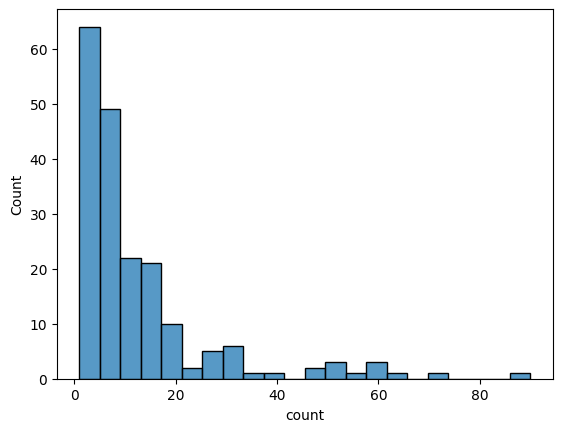

In [224]:
sns.histplot(unique_dishes_df['countries_of_origin'].explode().value_counts())

### Collapse similar ingredient variants (plural, spacing, accents, etc.)

In [225]:
import inflect
import unicodedata
import re

p = inflect.engine()

# Normalize ingredient strings to collapse accent, apostrophe, and hyphen variants,
# while preserving spaces so canonical multi-word ingredients stay spaced.
def normalize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = unicodedata.normalize('NFKD', ingredient)
    ingredient = ''.join(ch for ch in ingredient if not unicodedata.combining(ch))
    ingredient = ingredient.lower()
    ingredient = ingredient.replace('-', ' ')
    ingredient = re.sub(r"[’`´]", "'", ingredient)
    ingredient = ingredient.replace("'", '')
    ingredient = re.sub(r'\s+', ' ', ingredient).strip()
    return ingredient

# Singularize ingredients after normalization
def singularize_ingredient(ingredient):
    if not isinstance(ingredient, str):
        return ingredient
    ingredient = normalize_ingredient(ingredient)
    try:
        return p.singular_noun(ingredient) or ingredient
    except Exception:
        return ingredient

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [singularize_ingredient(ing) for ing in lst]
)

# Map joined variants to spaced canonical forms when a spaced form exists.
joined_to_spaced = {}
for ing in unique_dishes_df.loc[:, 'ingredients'].explode().dropna().unique():
    joined = ing.replace(' ', '')
    if ' ' in ing:
        joined_to_spaced[joined] = ing

unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(
    lambda lst: [joined_to_spaced.get(ing.replace(' ', ''), ing) for ing in lst]
)


In [226]:
from fuzzywuzzy import fuzz
from itertools import combinations

ingredients = unique_dishes_df['ingredients'].explode().dropna().unique()
pairs = list(combinations(ingredients, 2))

# Calculate similarities
similarities = [(pair, fuzz.ratio(pair[0], pair[1])) for pair in pairs]
similarities.sort(key=lambda x: x[1], reverse=True)

In [227]:
similarities[:40]

[(('pomegranate seed', 'pomgranate seed'), 97),
 (('sausage casing', 'sausages casing'), 97),
 (('corn starch', 'acorn starch'), 96),
 (('goats milk', 'goat milk'), 95),
 (('sheep milk', 'sheeps milk'), 95),
 (('pig blood', 'pigs blood'), 95),
 (('pig tail', 'pigs tail'), 94),
 (('red chili pepper', 'dried chili pepper'), 94),
 (('gelatin', 'gelatine'), 93),
 (('spaetzle', 'spatzle'), 93),
 (('sodium nitrite', 'sodium nitrate'), 93),
 (('habanero pepper', 'habenero pepper'), 93),
 (('chili pepper', 'chile pepper'), 92),
 (('dried shrimp', 'fried shrimp'), 92),
 (('pasilla chili', 'pasilla chile'), 92),
 (('artificial flavoring', 'artificial flavor'), 92),
 (('locoto pepper', 'rocoto pepper'), 92),
 (('green chili', 'green chile'), 91),
 (('powdered sugar for dusting', 'powdered sugar for frosting'), 91),
 (('dried fish', 'fried fish'), 90),
 (('red onion', 'fried onion'), 90),
 (('red chili pepper flake', 'chili pepper flake'), 90),
 (('dried chili', 'red chili'), 90),
 (('dried red ch

In [228]:
unique_dishes_df['ingredients'].explode().value_counts().head(10)

ingredients
salt      765
garlic    571
onion     487
sugar     428
water     330
egg       297
butter    296
pepper    274
flour     234
tomato    210
Name: count, dtype: int64

### Trying to make connections between base and processed ingredient names...

In [229]:
ingredients = unique_dishes_df['ingredients'].explode()

one_word_ingredients = ingredients[ingredients.str.split().str.len() == 1]

len(one_word_ingredients.value_counts())


541

In [230]:
most_common_200 = one_word_ingredients.value_counts().head(200).index.tolist()
# if one of words of ingredients of dish is in the most common 50 ingredients, add the one-word ingredient to the dish's ingredient list (if not already present)
def get_base_ingredient_names(ingredient_list):
    base_ingredients = []
    for ingredient in ingredient_list:
        for word in ingredient.split():
            if word in most_common_200 and word not in base_ingredients:
                base_ingredients.append(word)
    return base_ingredients

def add_base_ingredients(ingredient_list):
    base_ingredients = get_base_ingredient_names(ingredient_list)
    return list(set(ingredient_list) | set(base_ingredients))

In [231]:
add_base_ingredients(["green onion", "red onion", "minced garlic", "garlic", "chicken", "rice", "ube jam"])

['red onion',
 'ube',
 'onion',
 'chicken',
 'jam',
 'garlic',
 'ube jam',
 'green onion',
 'rice',
 'minced garlic']

In [232]:
unique_dishes_df.loc[:, 'ingredients'] = unique_dishes_df.loc[:, 'ingredients'].apply(add_base_ingredients)
unique_dishes_df.loc[0, 'ingredients']

['onion',
 'ground meat',
 'dill',
 'garlic',
 'bacon',
 'pepper',
 'potato',
 'egg',
 'salt',
 'meat',
 'mushroom',
 'sour cream',
 'cream']

### misc

In [233]:
def display_ingredients(dish_name):
    ingredients = cleaned_df.loc[cleaned_df['dish_name'] == dish_name, 'ingredients'].values
    if len(ingredients) > 0:
        return ", ".join(ingredients[0])
    else:
        return []

# Models

**Will be useful to refactor and do GridSearchCV on RandomForest model varying num trees, max depth, balancing parameter, and uncommon country training drop size**

In [234]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# Keep the full multi-country lists for evaluation, but split before assigning single labels.
model_df = unique_dishes_df[unique_dishes_df['countries_of_origin'].map(bool)].copy()
train_df, test_df = train_test_split(model_df, test_size=0.2, random_state=42)

# Compute the most common country labels from the training set only.
train_country_counts = train_df['countries_of_origin'].explode().value_counts()

def most_common_country(country_list):
    if not country_list:
        return np.nan
    ranked = sorted(country_list, key=lambda c: train_country_counts.get(c, 0), reverse=True)
    return ranked[0]

# convert multi-label to single-label for training by taking the most common country in the training set among the valid countries for each dish
#train_df['target_country'] = train_df['countries_of_origin'].apply(most_common_country)

# expand multi-labels into separate rows for training, 1 row per dish-country_of_origin pair
train_df = train_df.explode('countries_of_origin').rename(columns={'countries_of_origin': 'target_country'}).reset_index(drop=True)

# filter out less common countries from the training set to reduce noise
uncommon_countries = train_country_counts.tail(150).index
train_df = train_df[~train_df['target_country'].isin(uncommon_countries)]


mlb = MultiLabelBinarizer(sparse_output=False)
mlb.fit(model_df['ingredients'])
X_train = pd.DataFrame(mlb.transform(train_df['ingredients']), columns=mlb.classes_, index=train_df.index)
X_test = pd.DataFrame(mlb.transform(test_df['ingredients']), columns=mlb.classes_, index=test_df.index)

y_train = train_df['target_country']
y_test_multi = test_df['countries_of_origin']

print('Training rows:', len(train_df))
print('Test rows:', len(test_df))
print('Training country counts:', y_train.value_counts().head(10).to_dict())
print('Example test labels (multi-country):', y_test_multi.head().tolist())


Training rows: 959
Test rows: 277
Training country counts: {'United States': 74, 'Japan': 59, 'China': 50, 'Italy': 49, 'Indonesia': 49, 'Philippines': 47, 'United Kingdom': 43, 'Spain': 41, 'India': 40, 'South Korea': 38}
Example test labels (multi-country): [['Canada'], ['Indonesia'], ['Nicaragua', 'Belize', 'Panama', 'Guatemala', 'Costa Rica', 'Honduras', 'El Salvador'], ['Cambodia', 'Philippines', 'Vietnam', 'Laos', 'Thailand'], ['United States']]


### Decision Tree

In [235]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# example display count
n = 8
display_ings = False

clf = DecisionTreeClassifier(max_depth = 150, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())


Train set: (959, 2007) Test set: (277, 2007)
Hold-out accuracy (single-label prediction vs. any true country): 0.21299638989169675

Predicted vs actual multi-country labels for first examples:
All-dressed Chips: predicted United Kingdom, actual=['Canada'], incorrect
Saksang: predicted Thailand, actual=['Indonesia'], incorrect
Rellenitos De Plátano: predicted United States, actual=['Nicaragua', 'Belize', 'Panama', 'Guatemala', 'Costa Rica', 'Honduras', 'El Salvador'], incorrect
Balut: predicted Mexico, actual=['Cambodia', 'Philippines', 'Vietnam', 'Laos', 'Thailand'], incorrect
Gerber Sandwich: predicted France, actual=['United States'], incorrect
Chiura: predicted India, actual=['Nepal'], incorrect
Wat: predicted China, actual=['Eritrea', 'Ethiopia'], incorrect
Simnel Cake: predicted United Kingdom, actual=['United Kingdom'], correct

Top ingredient importances:
sugar         0.023408
mirin         0.023174
olive oil     0.021108
shallot       0.020354
garlic        0.018076
sesame oil

In [236]:
display_ingredients('Qarymutah')

'bulgur, onion, cucumber, tomato, parsley, lemon juice, mint, sumac'

How did it go USA.........

In [237]:
y_train[y_train == 'Syria']

Series([], Name: target_country, dtype: object)

It turns out setting the training label to the most frequent of the valid countries filters out Syria entirely

### Random Forest

In [238]:
from sklearn.ensemble import RandomForestClassifier

# example display count
n = 8
display_ings = False

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (959, 2007) Test set: (277, 2007)
Hold-out accuracy (single-label prediction vs. any true country): 0.37906137184115524

Predicted vs actual multi-country labels for first examples:
All-dressed Chips: predicted United States, actual=['Canada'], incorrect
Saksang: predicted Indonesia, actual=['Indonesia'], correct
Rellenitos De Plátano: predicted France, actual=['Nicaragua', 'Belize', 'Panama', 'Guatemala', 'Costa Rica', 'Honduras', 'El Salvador'], incorrect
Balut: predicted India, actual=['Cambodia', 'Philippines', 'Vietnam', 'Laos', 'Thailand'], incorrect
Gerber Sandwich: predicted United States, actual=['United States'], correct
Chiura: predicted India, actual=['Nepal'], incorrect
Wat: predicted Philippines, actual=['Eritrea', 'Ethiopia'], incorrect
Simnel Cake: predicted United Kingdom, actual=['United Kingdom'], correct

Top ingredient importances:
salt            0.011555
oil             0.010554
lime            0.010546
egg             0.010389
sesame oil      0.009919

In [239]:
pd.Series(y_pred).value_counts() / len(y_pred) * 100

Germany           8.664260
United States     8.303249
United Kingdom    6.859206
Japan             6.859206
Italy             6.859206
India             6.498195
Spain             6.137184
France            5.776173
Philippines       5.776173
China             3.971119
Mexico            3.971119
Turkey            3.971119
Indonesia         3.249097
Iran              2.888087
South Korea       2.527076
Thailand          2.527076
Peru              2.166065
Georgia           2.166065
Poland            1.805054
Sweden            1.444043
Vietnam           1.444043
Australia         1.083032
Brazil            1.083032
Malaysia          1.083032
Canada            1.083032
North Korea       1.083032
Hong Kong         0.361011
Azerbaijan        0.361011
Name: count, dtype: float64

### Balanced Random Forest

In [240]:
from imblearn.ensemble import BalancedRandomForestClassifier

# example display count
n = 8
display_ings = False

clf = BalancedRandomForestClassifier(random_state=42, n_estimators=300, max_depth=30, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual, dish in zip(y_pred, y_test_multi.head(n), test_df['dish_name'].head(n)):
    print(f'{dish}: predicted {pred}, actual={actual}, {"correct" if pred in actual else "incorrect"}')
    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (959, 2007) Test set: (277, 2007)
Hold-out accuracy (single-label prediction vs. any true country): 0.2996389891696751

Predicted vs actual multi-country labels for first examples:
All-dressed Chips: predicted Georgia, actual=['Canada'], incorrect
Saksang: predicted Malaysia, actual=['Indonesia'], incorrect
Rellenitos De Plátano: predicted France, actual=['Nicaragua', 'Belize', 'Panama', 'Guatemala', 'Costa Rica', 'Honduras', 'El Salvador'], incorrect
Balut: predicted Mexico, actual=['Cambodia', 'Philippines', 'Vietnam', 'Laos', 'Thailand'], incorrect
Gerber Sandwich: predicted United Kingdom, actual=['United States'], incorrect
Chiura: predicted India, actual=['Nepal'], incorrect
Wat: predicted Georgia, actual=['Eritrea', 'Ethiopia'], incorrect
Simnel Cake: predicted United Kingdom, actual=['United Kingdom'], correct

Top ingredient importances:
salt            0.011701
oil             0.011106
water           0.011023
onion           0.010907
egg             0.010595
rice 

### XGBoost

In [241]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# example display count
n = 8
display_ings = False

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)

clf = XGBClassifier(random_state=42, n_estimators=50, max_depth=5, learning_rate=0.1, objective='multi:softmax', num_class=len(le.classes_))  #####################################################
clf.fit(X_train, y_train_encoded)
y_pred = clf.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred)

# Count a test prediction as correct if it matches any of the true countries for that dish.
correct_matches = [(pred in actual_list) for pred, actual_list in zip(y_pred_labels, y_test_multi)]
accuracy_multi = sum(correct_matches) / len(correct_matches)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)
print('Hold-out accuracy (single-label prediction vs. any true country):', accuracy_multi)
print('\nPredicted vs actual multi-country labels for first examples:')
for pred, actual_list, dish in zip(
    y_pred_labels,
    y_test_multi.head(n),
    test_df['dish_name'].head(n)
):
    actual_list = actual_list if isinstance(actual_list, (list, tuple)) else [actual_list]

    print(f'{dish}: predicted {pred}, actual={actual_list}, {"correct" if pred in actual_list else "incorrect"}')

    if display_ings:
        print(f'{display_ingredients(dish)}\n')

feature_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
print('\nTop ingredient importances:')
print(feature_importances.head(15).to_string())

Train set: (959, 2007) Test set: (277, 2007)
Hold-out accuracy (single-label prediction vs. any true country): 0.3140794223826715

Predicted vs actual multi-country labels for first examples:
All-dressed Chips: predicted United States, actual=['Canada'], incorrect
Saksang: predicted Singapore, actual=['Indonesia'], incorrect
Rellenitos De Plátano: predicted France, actual=['Nicaragua', 'Belize', 'Panama', 'Guatemala', 'Costa Rica', 'Honduras', 'El Salvador'], incorrect
Balut: predicted Iran, actual=['Cambodia', 'Philippines', 'Vietnam', 'Laos', 'Thailand'], incorrect
Gerber Sandwich: predicted United States, actual=['United States'], correct
Chiura: predicted India, actual=['Nepal'], incorrect
Wat: predicted Philippines, actual=['Eritrea', 'Ethiopia'], incorrect
Simnel Cake: predicted United Kingdom, actual=['United Kingdom'], correct

Top ingredient importances:
mustard seed      0.051042
mirin             0.043836
ghee              0.022316
garam masala      0.019602
olive oil       

# Model CV

# Prediction!

In [242]:
def preprocess_ingredients(ingredient_string):
    cleaned_list = clean_ingredient_list(strip_optional_tags(ingredient_string))
    normalized_list = [normalize_ingredient(ing) for ing in cleaned_list]
    singularized_list = [singularize_ingredient(ing) for ing in normalized_list]
    return singularized_list

In [243]:
def predict_country(ingredient_string):
    # Preprocess the ingredients
    processed_ings = preprocess_ingredients(ingredient_string)
    print(f"Processed ingredients: {processed_ings}")

    # Create feature vector
    X_new = pd.DataFrame(mlb.transform([processed_ings]), columns=mlb.classes_)

    # Train and predict with Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_new)[0]

    probs = rf_model.predict_proba(X_new)
    top_n = 5
    top_n_indices = np.argsort(probs, axis=1)[:, :-top_n-1:-1]
    top_n_predictions = rf_model.classes_[top_n_indices]

    print(f"Random Forest prediction: {rf_pred}")
    print(f"2nd prediction: {top_n_predictions[0][1]}")
    print(f"3rd prediction: {top_n_predictions[0][2]}")
    print(f"4th prediction: {top_n_predictions[0][3]}")
    print(f"5th prediction: {top_n_predictions[0][4]}")


In [244]:
predict_country("Cabbage, carrots, radishes, ginger, garlic, chili peppers, salt, water, Sichuan peppercorns, sugar (optional), rice vinegar (optional).")

Processed ingredients: ['cabbage', 'carrot', 'radish', 'ginger', 'garlic', 'chili pepper', 'salt', 'water', 'sichuan peppercorn', 'sugar', 'rice vinegar']
Random Forest prediction: China
2nd prediction: Japan
3rd prediction: Philippines
4th prediction: South Korea
5th prediction: North Korea


In [245]:
predict_country("Rice, water, salt (optional).")

Processed ingredients: ['rice', 'water', 'salt']
Random Forest prediction: Japan
2nd prediction: India
3rd prediction: United States
4th prediction: China
5th prediction: South Korea


In [246]:
predict_country("Wheat flour, butter, milk, egg yolk, sugar, ground almonds, ground hazelnuts, ground walnuts, cardamom, (optional saffron), (optional rose water), (optional vanilla), (optional baking powder), (optional salt)")

Processed ingredients: ['wheat flour', 'butter', 'milk', 'egg yolk', 'sugar', 'ground almond', 'ground hazelnut', 'ground walnut', 'cardamom', 'saffron', 'rose water', 'vanilla', 'baking powder', 'salt']


/home/rhemmati/.local/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['ground hazelnut'] will be ignored
  warnings.warn(


Random Forest prediction: India
2nd prediction: Iran
3rd prediction: Canada
4th prediction: United States
5th prediction: Sweden


In [247]:
predict_country("rice, onion, walnut, pomegranate paste, chicken, turmeric")

Processed ingredients: ['rice', 'onion', 'walnut', 'pomegranate paste', 'chicken', 'turmeric']
Random Forest prediction: India
2nd prediction: Japan
3rd prediction: United States
4th prediction: Azerbaijan
5th prediction: Hong Kong
